<a href="https://colab.research.google.com/github/JakeOh/202511_BD53/blob/main/lab_ml/ml20_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN(Recurrent Neural Network, 순환 신경망)

시계열 데이터, 자연어 처리, 자율 주행 등의 분야에 좋은 성능을 주는 신경망.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split

# IMDB 데이터셋

*   imdb.com 사이트 사용자들의 영화 리뷰를 긍정(1), 부정(0)으로 분류한 데이터.
*   25,000개 훈련 샘플과 25,000개의 테스트 샘플.
*   샘플마다 단어(토큰, token)의 개수가 다름.
    *   샘플마다 특성(feature)의 개수가 다름 --> 전처리
*   keras datasets에서 다운받은 데이터는 단어들이 인코딩된 상태.
*   (참고) KoNLP 라이브러리 - 한국어 자연어 처리 라이브러리.

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=500)
# num_words=500: 가장 자주 등장하는 단어 500개를 어휘 사전으로 사용함.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train_full.shape  #> (25_000,) 모양의 1차원 배열 - 25,000개 영화 리뷰

(25000,)

In [4]:
y_train_full.shape  # (25_000,) 모양의 1차원 배열 - 25,000개 영활 리뷰의 긍정/부정

(25000,)

In [5]:
np.unique(y_train_full, return_counts=True)  # 긍정/부정 리뷰는 12,500개씩

(array([0, 1]), array([12500, 12500]))

In [6]:
x_test.shape

(25000,)

In [7]:
y_test.shape

(25000,)

In [8]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([12500, 12500]))

## 훈련 셋 탐색

In [9]:
print(x_train_full[0])  # 첫번째 훈련 샘플

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [10]:
print(type(x_train_full[0]))  # 첫번째 훈련 샘플 list 타입 - 정수들의 리스트

<class 'list'>


In [11]:
print(len(x_train_full[0]))  # 첫번째 훈련 샘플의 길이는 218

218


In [12]:
print(x_train_full[1])  # 두번째 훈련 샘플

[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 2, 8, 118, 2, 14, 394, 20, 13, 119, 2, 189, 102, 5, 207, 110, 2, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2, 2, 5, 2, 4, 116, 9, 35, 2, 4, 229, 9, 340, 2, 4, 118, 9, 4, 130, 2, 19, 4, 2, 5, 89, 29, 2, 46, 37, 4, 455, 9, 45, 43, 38, 2, 2, 398, 4, 2, 26, 2, 5, 163, 11, 2, 2, 4, 2, 9, 194, 2, 7, 2, 2, 349, 2, 148, 2, 2, 2, 15, 123, 125, 68, 2, 2, 15, 349, 165, 2, 98, 5, 4, 228, 9, 43, 2, 2, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 2, 228, 2, 5, 2, 2, 245, 2, 5, 4, 2, 131, 152, 491, 18, 2, 32, 2, 2, 14, 9, 6, 371, 78, 22, 2, 64, 2, 9, 8, 168, 145, 23, 4, 2, 15, 16, 4, 2, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]


In [13]:
print(len(x_train_full[1]))  # 두번째 훈련 샘플의 길이는 189

189


imdb 데이터셋은 파이썬의 list 객체들을 원소로 갖는 **1차원 ndarray**.

각각의 리스트들은 정수들을 저장. 정수들은 영화 리뷰에 사용된 단어(토큰)를 의미.

각각의 리스트들은 길이가 다름.

In [14]:
for i in range(5):
    print(f'인덱스 {i}: 토큰 개수 = {len(x_train_full[i])}')

인덱스 0: 토큰 개수 = 218
인덱스 1: 토큰 개수 = 189
인덱스 2: 토큰 개수 = 141
인덱스 3: 토큰 개수 = 550
인덱스 4: 토큰 개수 = 147


In [15]:
for i in range(5):
    print(x_train_full[i][:30])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480]
[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 2, 8, 118, 2, 14, 394, 20, 13, 119, 2, 189, 102, 5, 207, 110]
[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 2, 54, 61, 369, 13, 71, 149, 14, 22, 112, 4, 2, 311, 12, 16, 2, 33, 75]
[1, 4, 2, 2, 33, 2, 4, 2, 432, 111, 153, 103, 4, 2, 13, 70, 131, 67, 11, 61, 2, 2, 35, 2, 2, 61, 2, 452, 2, 4]
[1, 249, 2, 7, 61, 113, 10, 10, 13, 2, 14, 20, 56, 33, 2, 18, 457, 88, 13, 2, 2, 45, 2, 13, 70, 79, 49, 2, 2, 13]


## 단어 인덱스(word index)

In [16]:
# get_word_index() 함수: 단어를 키로 하고, 그 단어의 인덱스(빈도수 순위)를 값으로 갖는 dict를 다운로드.
# 영화 리뷰의 단어들을 숫자로 인코딩할 때 인덱스들을 이용하기 위해서 만들어진 사전.
# 인덱스가 작을 수록 빈도수 순위가 높음.
word_index = keras.datasets.imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
print(type(word_index))

<class 'dict'>


In [18]:
for i, (k, v) in enumerate(word_index.items()):
    print(k, ':', v)
    if i == 9:
        break

fawn : 34701
tsukino : 52006
nunnery : 52007
sonja : 16816
vani : 63951
woods : 1408
spiders : 16115
hanging : 2345
woody : 2289
trawling : 52008


word_index를 인덱스를 키로 하고, 단어를 값으로 갖는 dict로 변환.

*   0: padding(패딩)
*   1: 문장의 시작
*   2: load_data() 함수의 아규먼트 num_words에 포함되지 않은 단어들. n개의 어휘 사전에 포함되지 않은 단어.

In [19]:
start_idx = 1  # 문장의 시작
oov_idx = 2  # n개의 어휘 사전에 없는 단어(out of value)
idx_from = 3
index_word = {(v + idx_from):k for k, v in word_index.items()}

In [20]:
index_word[start_idx] = '[START]'
index_word[oov_idx] = '[OOV]'

In [21]:
for i in range(1, 11):
    print(i, ':', index_word.get(i))

1 : [START]
2 : [OOV]
3 : None
4 : the
5 : and
6 : a
7 : of
8 : to
9 : is
10 : br


In [22]:
# 샘플의 인코딩된 숫자들을 단어로 변환하는 함수
def decode_review(review):
    # review: 숫자들의 리스트
    return ' '.join([index_word.get(i) for i in review])

In [23]:
decode_review(x_train_full[0])

"[START] this film was just [OOV] [OOV] [OOV] [OOV] story direction [OOV] really [OOV] the part they played and you could just [OOV] being there [OOV] [OOV] is an amazing actor and now the same being director [OOV] father came from the same [OOV] [OOV] as [OOV] so i loved the fact there was a real [OOV] with this film the [OOV] [OOV] throughout the film were great it was just [OOV] so much that i [OOV] the film as [OOV] as it was [OOV] for [OOV] and would recommend it to everyone to watch and the [OOV] [OOV] was amazing really [OOV] at the end it was so [OOV] and you know what they say if you [OOV] at a film it must have been good and this definitely was also [OOV] to the two little [OOV] that played the [OOV] of [OOV] and [OOV] they were just [OOV] children are often left out of the [OOV] [OOV] i think because the stars that play them all [OOV] up are such a big [OOV] for the whole film but these children are amazing and should be [OOV] for what they have done don't you think the whol

In [24]:
decode_review(x_train_full[1])

"[START] big [OOV] big [OOV] bad music and a [OOV] [OOV] [OOV] these are the [OOV] to best [OOV] this terrible movie i love [OOV] horror movies and i've seen [OOV] but this had got to be on of the worst ever made the plot is [OOV] [OOV] and [OOV] the acting is an [OOV] the script is completely [OOV] the best is the end [OOV] with the [OOV] and how he [OOV] out who the killer is it's just so [OOV] [OOV] written the [OOV] are [OOV] and funny in [OOV] [OOV] the [OOV] is big [OOV] of [OOV] [OOV] men [OOV] those [OOV] [OOV] [OOV] that show off their [OOV] [OOV] that men actually [OOV] them and the music is just [OOV] [OOV] that plays over and over again in almost every scene there is [OOV] music [OOV] and [OOV] [OOV] away [OOV] and the [OOV] still doesn't close for [OOV] all [OOV] [OOV] this is a truly bad film [OOV] only [OOV] is to look back on the [OOV] that was the [OOV] and have a good old laugh at how bad everything was back then"

## 각 샘플(영화 리뷰)의 길이 분포

In [25]:
review_lengths = pd.Series([len(x) for x in x_train_full])

In [26]:
review_lengths.describe()  # 수치 데이터 기술 통계량(평균, 표준편차, 최솟값, ...)

,0
count,25000.000000
mean,238.713640
std,176.497204
min,11.000000
25%,130.000000
50%,178.000000
75%,291.000000
max,2494.000000


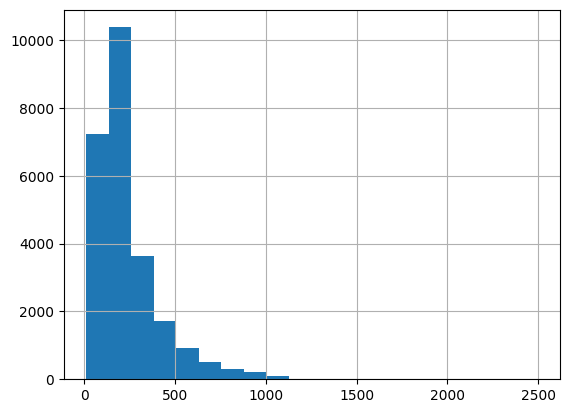

In [27]:
review_lengths.hist(bins=20)  # 히스토그램
plt.show()

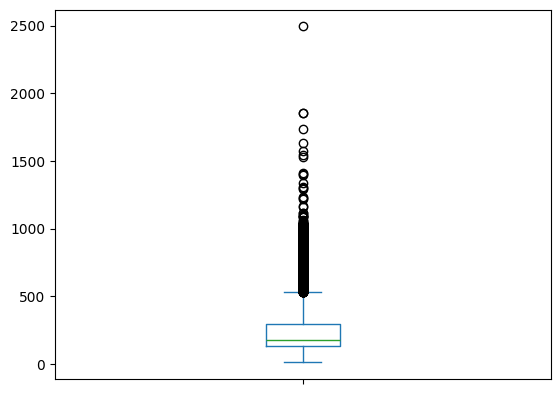

In [28]:
review_lengths.plot.box()  # box plot
plt.show()

영화 리뷰에서 사용된 단어 개수의 평균은 238개, 중앙값은 178개.

리뷰에서 사용된 단어 개수가 매우 많은(예를 들면 2400개) 리뷰들이 평균을 높여줌.

대부분의 영화 리뷰에서 사용된 단어의 개수는 300개 미만.

영화 리뷰 샘플마다 100개의 단어(토큰)만 사용. 길이가 100 이상인 샘플들은 잘라내야 하고, 길이가 100 미만인 샘플들은 0으로 채움(패딩).

## Data Wrangling

(25_000,) 모양의 1차원 배열(훈련 셋, 테스트 셋)을 (25_000, 100) 모양인 2차원 배열(ndarray) 변환.

`keras.preprocessing.sequence.pad_sequence()` 함수 파라미터:
*   `sequences`: 변환할 데이터
*   `maxlen`: 각 샘플의 최대 길이
*   `padding`: 샘플의 길이가 `maxlen`보다 짧을 때 패딩을 넣는 위치. 기본값은 'pre'. 패딩값(0)을 시퀀스의 앞쪽에 채움.
*   `truncate`: 샘플의 길이가 `maxlen`보다 길 때 샘플을 자르는 위치. 기본값은 'pre'. 시퀀스의 앞쪽을 자름.
*   순환신경망을 사용할 때는 `padding`과 `truncate` 모두 'pre' 방식을 선호.

In [29]:
x_train_full_seq = keras.preprocessing.sequence.pad_sequences(sequences=x_train_full, maxlen=100)
# padding='pre', truncate='pre': 기본값

In [30]:
x_train_full_seq.shape

(25000, 100)

In [31]:
x_test_seq = keras.preprocessing.sequence.pad_sequences(sequences=x_test, maxlen=100)

In [32]:
x_test_seq.shape

(25000, 100)

In [33]:
x_train_full_seq[0]  #> 리뷰의 앞부분이 잘리고 뒷부분의 100개 단어가 선택됨.

array([  2,  33,   6,  22,  12, 215,  28,  77,  52,   5,  14, 407,  16,
        82,   2,   8,   4, 107, 117,   2,  15, 256,   4,   2,   7,   2,
         5,   2,  36,  71,  43,   2, 476,  26, 400, 317,  46,   7,   4,
         2,   2,  13, 104,  88,   4, 381,  15, 297,  98,  32,   2,  56,
        26, 141,   6, 194,   2,  18,   4, 226,  22,  21, 134, 476,  26,
       480,   5, 144,  30,   2,  18,  51,  36,  28, 224,  92,  25, 104,
         4, 226,  65,  16,  38,   2,  88,  12,  16, 283,   5,  16,   2,
       113, 103,  32,  15,  16,   2,  19, 178,  32], dtype=int32)

In [34]:
print(x_train_full[0][-100:])

[2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [35]:
for i in range(25_000):
    if x_train_full_seq[i, 0] == 0:
        print(x_train_full_seq[i])
        break
#> 리뷰의 앞쪽에 0으로 패딩이 채워짐.

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   1   2 128  74  12   2 163  15   4   2   2   2   2  32  85
 156  45  40 148 139 121   2   2  10  10   2 173   4   2   2  16   2   8
   4 226  65  12  43 127  24   2  10  10]


*   FFNN(Feed-Forward Neural Network): 데이터의 흐름이 앞으로만 전달되는 신경망
    *   완전연결 신경망
    *   합성곱 신경망(CNN)
*   RNN(Recurrent Neural Network): 순환 신경망
    *   순차 데이터(sequential data): 순환 신경망에서 사용하는 데이터. 텍스트(문장) 또는 시계열 데이터처럼 순서가 중요한 데이터.
    *   타임 스텝(time step): 샘플을 처리하는 한 단계. 시퀀스의 각 원소들을 순서대로 처리하는 단계.
    *   셀(cell): 순환 신경망 층(recurrent layer)의 유닛(뉴런).
        *   Dense에서 unit, Conv2D에서 filter와 비슷한 개념.
    *   은닉 상태(hidden state): 셀의 출력
    *   시퀀스(sequence): 순환 신경망에서 사용하는 하나의 샘플.
    *   자연어 처리(NLP, Natural Language Processing)와 같은 경우, 단어들을 숫자로 인코딩을 함. 인코딩된 숫자의 크기는 중요한 게 아님. 인코딩된 정수가 신경망으로 직접 주입되면 안됨.
        *   One-Hot Encoding
            *   단점: 계산량이 많아지고 메모리를 많이 사용하게 됨.
            *   CategoryEncoding 클래스를 이용.
        *   Word-Embedding
            *   One-Hot encoding의 단점을 보완.
            *   정수 1개를 몇 개의 실수들의 벡터로 인코딩.
            *   Embedding 클래스를 이용.

# One-Hot Encoding을 사용한 RNN

*   시퀀스로 변환된 전체 훈련 셋을 훈련/검증 셋으로 나눔.
*   신경망의 첫번째 층을 CategoryEncoding으로 설정.
*   SimpleRNN을 두번째 층으로 설정.
*   출력층을 설정.

In [36]:
x_train_seq, x_val_seq, y_train, y_val = train_test_split(x_train_full_seq, y_train_full,
                                                          test_size=0.2,
                                                          stratify=y_train_full,
                                                          random_state=42)

In [37]:
x_train_seq.shape

(20000, 100)

In [38]:
tf.random.set_seed(42)
np.random.seed(42)

In [39]:
rnn_1 = keras.Sequential(layers=[
    keras.Input(shape=(100,)),  # 입력층
    keras.layers.CategoryEncoding(num_tokens=500, output_mode='one_hot'),  # One-Hot encodig layer
    keras.layers.SimpleRNN(units=8),  # 순환층(8개 셀)
    keras.layers.Dense(units=1, activation='sigmoid')  # 출력층
])

*   `SimpleRNN` 생성자의 `activation` 파라미터의 기본값은 'tanh'.
*   `Dense` 생성자의 `activation` 파라미터의 기본값은 None.
    *   `activation=None`인 경우는, f(x)= x 선형 함수로 출력.
    *   이진분류 문제의 출력층 -> sigmoid
    *   다중클래스 분류 문제의 출력층 -> softmax
    *   회귀 문제의 출력층 -> 선형 함수.
    *   은닉층 -> 비선형 함수. sigmoid, tanh, relu, leaky_relu, elu

In [40]:
rnn_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ category_encoding               │ (None, 100, 500)       │             0 │
│ (CategoryEncoding)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
(500 + 8 + 1) * 8
# 1개의 time step의 특성 개수 = 500
# 각 셀에서의 순환 입력 = 8
# 바이어스(절편) = 1

4072

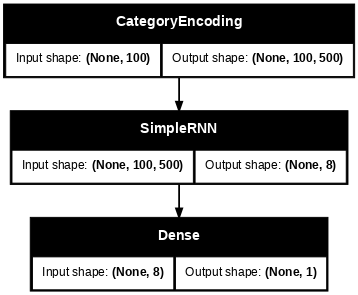

In [42]:
keras.utils.plot_model(model=rnn_1, dpi=64, show_shapes=True)

In [43]:
rnn_1.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.binary_crossentropy,
              metrics=[keras.metrics.binary_accuracy])

In [44]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath='rnn_1.keras', save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [45]:
result = rnn_1.fit(x=x_train_seq, y=y_train, batch_size=64, epochs=1_000,
                   validation_data=[x_val_seq, y_val],
                   callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - binary_accuracy: 0.5302 - loss: 0.6907 - val_binary_accuracy: 0.5392 - val_loss: 0.6857
Epoch 2/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - binary_accuracy: 0.5899 - loss: 0.6712 - val_binary_accuracy: 0.6426 - val_loss: 0.6416
Epoch 3/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - binary_accuracy: 0.7394 - loss: 0.5407 - val_binary_accuracy: 0.7266 - val_loss: 0.5507
Epoch 4/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - binary_accuracy: 0.7826 - loss: 0.4704 - val_binary_accuracy: 0.7604 - val_loss: 0.5024
Epoch 5/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - binary_accuracy: 0.8037 - loss: 0.4410 - val_binary_accuracy: 0.7640 - val_loss: 0.5102
Epoch 6/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - binary_accuracy: 0.8099 - loss: 0.4296 - val_binary_accuracy: 0.7692 - val_loss: 0.5101
Epoch 7/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - binary_accuracy: 0.8149 - loss: 0.4202 - val_binary_accuracy: 0.7746 - 

In [46]:
result.epoch  # 에포크 번호(인덱스)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [47]:
result.history  # 훈련 셋, 검증 셋의 정확도와 손실을 저장한 dict

{'binary_accuracy': [0.5302000045776367,
  0.5898500084877014,
  0.7393500208854675,
  0.7825999855995178,
  0.8036999702453613,
  0.8099499940872192,
  0.8148999810218811,
  0.8184499740600586,
  0.8222500085830688,
  0.8274999856948853],
 'loss': [0.6906647086143494,
  0.6712155938148499,
  0.5407385230064392,
  0.47041621804237366,
  0.4410175681114197,
  0.42958584427833557,
  0.42023539543151855,
  0.41376733779907227,
  0.40863361954689026,
  0.39876002073287964],
 'val_binary_accuracy': [0.5392000079154968,
  0.6425999999046326,
  0.7265999913215637,
  0.7603999972343445,
  0.7639999985694885,
  0.7692000269889832,
  0.7746000289916992,
  0.7738000154495239,
  0.7734000086784363,
  0.7721999883651733],
 'val_loss': [0.6856863498687744,
  0.6416405439376831,
  0.5506978631019592,
  0.5024070739746094,
  0.5101544260978699,
  0.5100510120391846,
  0.48910799622535706,
  0.4946221113204956,
  0.4950641989707947,
  0.50107741355896]}

## 모델 평가

In [48]:
def plot_train_val_loss(history):
    # history: History 클래스 객체 타입. fit() 메서드 리턴값.
    epochs = history.epoch
    history = history.history
    plt.plot(epochs, history['loss'], 'bo-', label='train loss')
    plt.plot(epochs, history['val_loss'], 'ro:', label='validation loss')
    plt.legend()
    plt.grid()
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

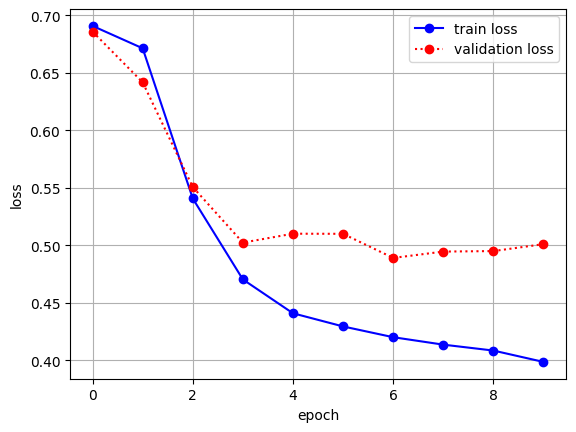

In [49]:
plot_train_val_loss(result)

In [50]:
# 훈련 셋 정확도
rnn_1.evaluate(x=x_train_seq, y=y_train)

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - binary_accuracy: 0.8291 - loss: 0.3959


[0.39594152569770813, 0.8291000127792358]

In [52]:
# 검증 셋 정확도
rnn_1.evaluate(x=x_val_seq, y=y_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.7746 - loss: 0.4891


[0.4891081154346466, 0.7746000289916992]

# Word-Embedding을 사용한 RNN

In [88]:
x_train_seq.shape

(20000, 100)

In [89]:
x_val_seq.shape

(5000, 100)

In [90]:
tf.random.set_seed(42)
np.random.seed(42)

In [91]:
rnn_2 = keras.Sequential(layers=[
    keras.Input(shape=(100,)),  # 입력층
    keras.layers.Embedding(input_dim=500, output_dim=16),  # 단어 임베딩 층
    keras.layers.SimpleRNN(units=8),  # RNN 층
    keras.layers.Dense(units=1, activation='sigmoid')  # 출력층
])

In [92]:
rnn_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Word-Embedding 계층의 모델 파라미터 개수
500 * 16  # 리뷰에 사용된 단어(500) x 1개 단어마다 16개의 실수로 변환(임베딩)

8000

In [94]:
# SimpleRNN 계층의 모델 파라미터 개수
(16 + 8 + 1) * 8
#> (타임 스텝(단어 1개)의 특성 개수(16) + 은닉상태(순환입력, 8) + bias(1)) * 셀 개수(8)

200

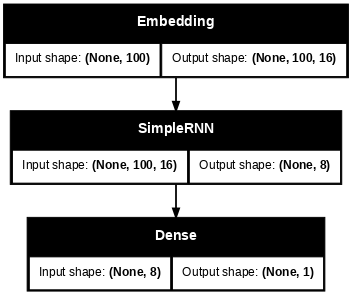

In [95]:
keras.utils.plot_model(model=rnn_2, dpi=64, show_shapes=True)

In [96]:
# 모델 컴파일
rnn_2.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.binary_crossentropy,
              metrics=[keras.metrics.binary_accuracy])

In [97]:
# 콜백 객체 생성
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath='rnn_2.keras', save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [98]:
# 모델 훈련
result= rnn_2.fit(x=x_train_seq, y=y_train, batch_size=64, epochs=1_000,
                  validation_data=[x_val_seq, y_val],
                  callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - binary_accuracy: 0.5739 - loss: 0.6748 - val_binary_accuracy: 0.6256 - val_loss: 0.6485
Epoch 2/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - binary_accuracy: 0.6799 - loss: 0.6088 - val_binary_accuracy: 0.7204 - val_loss: 0.5704
Epoch 3/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - binary_accuracy: 0.6955 - loss: 0.5921 - val_binary_accuracy: 0.5990 - val_loss: 0.6609
Epoch 4/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 0.6554 - loss: 0.6151 - val_binary_accuracy: 0.6526 - val_loss: 0.6266
Epoch 5/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 0.7186 - loss: 0.5619 - val_binary_accuracy: 0.7220 - val_loss: 0.5564
Epoch 6/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - binary_accuracy: 0.7279 - loss: 0.5606 - val_binary_accuracy: 0.7232 - val_loss: 0.5657
Epoch 7/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - binary_accuracy: 0.7581 - loss: 0.5183 - val_binary_accuracy: 0.7270 - va

## 모델 평가

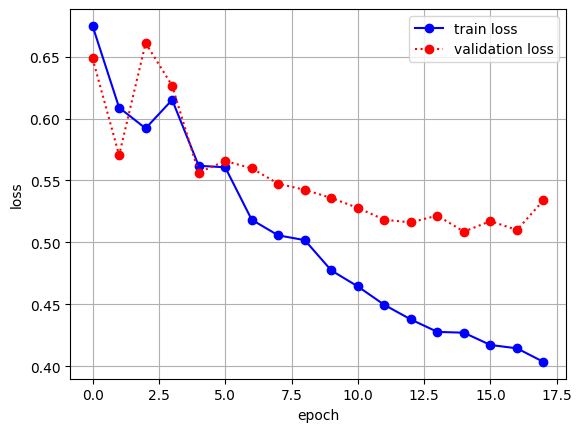

In [99]:
plot_train_val_loss(result)

In [100]:
# 훈련 셋 평가
rnn_2.evaluate(x=x_train_seq, y=y_train)

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8214 - loss: 0.4133


[0.41325896978378296, 0.821399986743927]

In [101]:
# 검증 셋
rnn_2.evaluate(x=x_val_seq, y=y_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.7678 - loss: 0.5087


[0.5086548328399658, 0.767799973487854]

# LSTM(Long Short-Term Memory, 장/단기 기억)

*   단기 기억을 오래 기억하기 위해서 고안된 순환 신경망
*   LSTM 셀 한 개는 입력 게이트, 삭제 게이트, 출력 게이트를 가지고 있음.
    *   입력 게이트: 새로운 정보를 셀 상태(cell state)에 추가. 단기 기억 저장.
    *   삭제 게이트: 셀 상태에 있는 정보를 제거. 장기 기억 삭제.
    *   출력 게이트: 다음 은닉 상태(hidden state)로 출력을 내보냄.
    *   LSTM 셀 한 개는 작은 순환 신경망 셀 4개로 이루어진 구조.

Input --> Word-Embedding --> LSTM --> Output

In [102]:
tf.random.set_seed(42)
np.random.seed(42)

# LSTM 모델 생성
lstm_1 = keras.Sequential(layers=[
    keras.Input(shape=(100,)),
    keras.layers.Embedding(input_dim=500, output_dim=32),
    keras.layers.LSTM(units=32),
    keras.layers.Dense(units=1, activation='sigmoid')  # 출력층
])

`LSTM` 생성자의 `activation` 파라미터의 기본값은 'tanh'(`SimpleRNN` 기본값과 같음).

In [103]:
lstm_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,353 (95.13 KB)

 Trainable params: 24,353 (95.13 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
# Embedding 계층의 파라미터 개수
500 * 32  #> 어휘 개수(input_dim) x 1개 단어를 임베딩하기 위한 실수 개수(output_dim)

16000

In [105]:
# LSTM 계층의 파라미터 개수
(32 + 32 + 1) * 4 * 32

8320

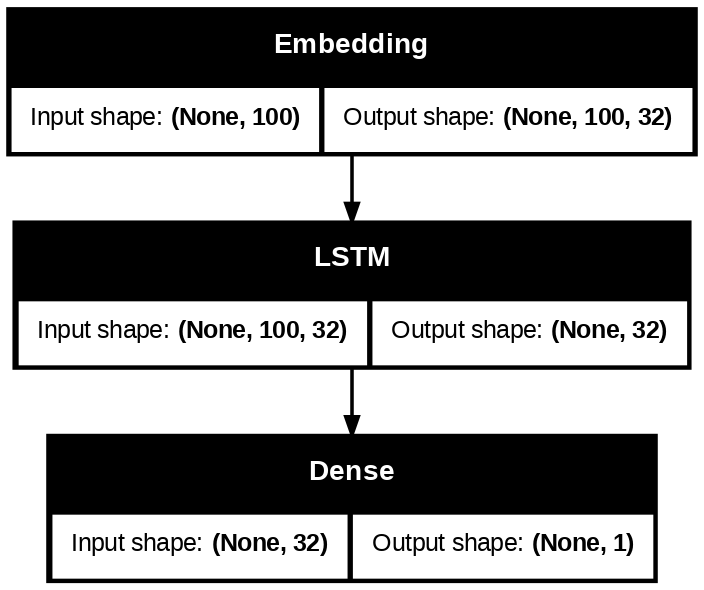

In [106]:
keras.utils.plot_model(model=lstm_1, show_shapes=True, dpi=128)

In [107]:
# 모델 컴파일
lstm_1.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.binary_crossentropy,
               metrics=[keras.metrics.binary_accuracy])

In [108]:
# 콜백 생성
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath='lstm_1.keras', save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [109]:
# 모델 훈련
result = lstm_1.fit(x=x_train_seq, y=y_train, batch_size=64, epochs=1_000,
                    validation_data=[x_val_seq, y_val],
                    callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - binary_accuracy: 0.7122 - loss: 0.5460 - val_binary_accuracy: 0.7326 - val_loss: 0.5330
Epoch 2/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - binary_accuracy: 0.7912 - loss: 0.4515 - val_binary_accuracy: 0.7812 - val_loss: 0.4578
Epoch 3/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - binary_accuracy: 0.8011 - loss: 0.4296 - val_binary_accuracy: 0.7816 - val_loss: 0.4544
Epoch 4/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - binary_accuracy: 0.8068 - loss: 0.4188 - val_binary_accuracy: 0.7820 - val_loss: 0.4521
Epoch 5/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - binary_accuracy: 0.8123 - loss: 0.4110 - val_binary_accuracy: 0.7860 - val_loss: 0.4483
Epoch 6/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - binary_accuracy: 0.8141 - loss: 0.4021 - val_binary_accuracy: 0.7976 - val_loss: 0.4444
Epoch 7/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - binary_accuracy: 0.8183 - loss: 0.3959 - val_binary_accuracy: 0.80

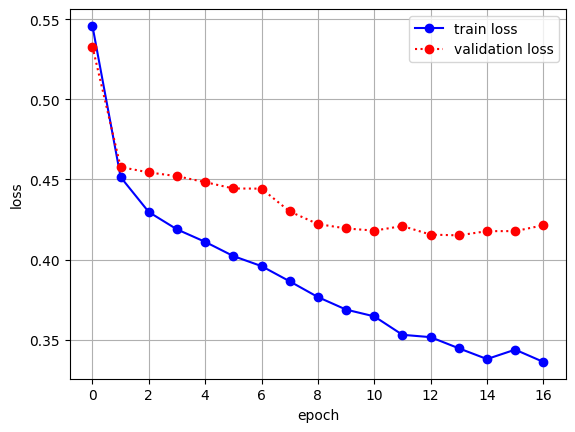

In [110]:
plot_train_val_loss(result)

## 모델 평가

In [111]:
lstm_1.evaluate(x=x_train_seq, y=y_train)

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - binary_accuracy: 0.8479 - loss: 0.3369


[0.3368578255176544, 0.8478500247001648]

In [112]:
lstm_1.evaluate(x=x_val_seq, y=y_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - binary_accuracy: 0.8090 - loss: 0.4151


[0.415082186460495, 0.8090000152587891]

# 2개 이상의 RNN을 연결

*   원래 순환층(SimpleRNN, LSTM, GRU)의 은닉 상태는 샘플의 마지막 타임 스텝의 은닉 상태만 그 다음 계층으로 전달.
*   순환층을 2개 이상 쌓게 되면 모든 순환층에서 순차 데이터(sequential data)가 필요함!
*   따라서 앞쪽 순환층이 모든 타임 스텝에 대한 은닉 상태를 출력해야 함. 시퀀스를 다음 순환층으로 입력해줘야 함.
*   오직 마지막 순환층에서만 마지막 타임 스텝의 은닉 상태만을 출력해야 함.
*   중간에 포함된 순환층에서는 `return_sequences` 파라미터 값을 True로 설정해야 함.
*   마지막 순환층에서만 `return_sequences=False`(기본값)로 설정하면 됨.

## 2개의 LSTM 층 연결

*   Input --> Embedding --> LSTM --> LSTM --> Dense
*   Embedding layer의 output_dim 파라미터는 32로 설정
*   첫번째 LSTM layer의 셀 개수는 32개. dropout의 비율을 0.2로 설정.
    *   return_sequences 파라미터 값을 설정.
*   두번째 LSTM layer의 셀 개수는 32개. dropout의 비율은 0.2로 설정.
    *   return_sequences 파라미터 값은 기본값을 그대로 사용.
*   출력층의 activation 함수는 sigmoid.

In [112]:
lstm_2 = keras.Sequential()